In [1]:
# Data analysis packages:
import pandas as pd
import numpy as np
#from datetime import datetime as dt

# Visualization packages:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
## Reading the dataset file name:
import os
print(os.listdir())

['.ipynb_checkpoints', 'EDA.ipynb', 'heatmaps.ipynb', 'KaggleV2-May-2016.csv', 'No-show-Issue-Comma-300k.csv', 'predicting_noshow.ipynb']


In [3]:
## Loading the dataset and printing out a few lines:
dataset = pd.read_csv('KaggleV2-May-2016.csv')
dataset.head(3)

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No


In [4]:
## Reading dataset general information:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
PatientId         110527 non-null float64
AppointmentID     110527 non-null int64
Gender            110527 non-null object
ScheduledDay      110527 non-null object
AppointmentDay    110527 non-null object
Age               110527 non-null int64
Neighbourhood     110527 non-null object
Scholarship       110527 non-null int64
Hipertension      110527 non-null int64
Diabetes          110527 non-null int64
Alcoholism        110527 non-null int64
Handcap           110527 non-null int64
SMS_received      110527 non-null int64
No-show           110527 non-null object
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


In [5]:
## Describing the numerical attributes:
dataset.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


In [6]:
## Checking the attribute data type:
type(dataset['PatientId'][0])

numpy.float64

In [7]:
## Converting the values to int type and then to str type:
dataset['PatientId'] = dataset['PatientId'].apply(lambda x: str(int(x)));

In [8]:
## Counting how many unique patients are in the dataset:
len(dataset['PatientId'].unique())

62299

In [9]:
## Checking the attribute data type:
type(dataset['AppointmentID'][0])

numpy.int64

In [10]:
## Converting the values to int type and then to str type:
dataset['AppointmentID'] = dataset['AppointmentID'].apply(lambda x: str(int(x)));

In [11]:
## Counting how many unique patients are in the dataset:
len(dataset['AppointmentID'].unique())

110527

In [12]:
dataset.set_index('AppointmentID', drop=True, inplace=True)

In [13]:
dataset[dataset['Age']<0]

,PatientId,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
AppointmentID,,,,,,,,,,,,,
5775010,465943158731293,F,2016-06-06T08:58:13Z,2016-06-06T00:00:00Z,-1,ROMÃO,0,0,0,0,0,0,No


In [14]:
dataset.drop('5775010',inplace=True)  #Removing the anomalous instance
# dataset.reset_index(drop=True,inplace=True)  #Reseting the dataset index

In [15]:
## Converting all 'Handcap' values higher than 0 to 1:
dataset['Handcap'] = np.where(dataset['Handcap']>0, 1, 0)

In [16]:
## Getting information of the categorical attributes:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 110526 entries, 5642903 to 5629448
Data columns (total 13 columns):
PatientId         110526 non-null object
Gender            110526 non-null object
ScheduledDay      110526 non-null object
AppointmentDay    110526 non-null object
Age               110526 non-null int64
Neighbourhood     110526 non-null object
Scholarship       110526 non-null int64
Hipertension      110526 non-null int64
Diabetes          110526 non-null int64
Alcoholism        110526 non-null int64
Handcap           110526 non-null int32
SMS_received      110526 non-null int64
No-show           110526 non-null object
dtypes: int32(1), int64(6), object(6)
memory usage: 11.4+ MB


In [17]:
## Counting gender classes
dataset.Gender.value_counts()

F    71839
M    38687
Name: Gender, dtype: int64

In [18]:
## Reading again the dataset first lines to get acquainted with its content:
dataset.head(2)

,PatientId,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
AppointmentID,,,,,,,,,,,,,
5642903,29872499824296,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
5642503,558997776694438,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No


In [19]:
## Converting the date information in string to datetime type:
dataset['ScheduledDay'] = pd.to_datetime(dataset.ScheduledDay)
dataset['AppointmentDay'] = pd.to_datetime(dataset.AppointmentDay)
## Creating a new column (attribute) containing just the scheduling time:
dataset['ScheduleTime'] = dataset.ScheduledDay.dt.time
## Normalizing the "Day" columns to keep just the date information (dropping the time info)
dataset['ScheduledDay'] = dataset.ScheduledDay.dt.normalize()

In [20]:
## Since both 'AppointmentDay' and 'ScheduledDay' are pandas.Timestamp type, this operation can be done directly:
dataset['WaitingDays'] = dataset['AppointmentDay'] - dataset['ScheduledDay']

In [23]:
def waiting_days(days):
    '''Auxiliary function to parse a date information from string type to python datetime object.
    Syntax: waiting_days(days), where:
        days = int type with the number of days considered.
    Return: a correspondent pandas._libs.tslib.Timedelta data type.
    '''
    arg = str(days) + ' days'
    return pd.Timedelta(arg)

In [24]:
## Checking which instances were scheduled after the appointment:
dataset[dataset['WaitingDays'] < waiting_days(0)]

,PatientId,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show,ScheduleTime,WaitingDays
AppointmentID,,,,,,,,,,,,,,,
5679978,7839272661752,M,2016-05-10 00:00:00+00:00,2016-05-09 00:00:00+00:00,38,RESISTÊNCIA,0,0,0,0,1,0,Yes,10:51:53,-1 days
5715660,7896293967868,F,2016-05-18 00:00:00+00:00,2016-05-17 00:00:00+00:00,19,SANTO ANTÔNIO,0,0,0,0,1,0,Yes,14:50:41,-1 days
5664962,24252258389979,F,2016-05-05 00:00:00+00:00,2016-05-04 00:00:00+00:00,22,CONSOLAÇÃO,0,0,0,0,0,0,Yes,13:43:58,-1 days
5686628,998231581612122,F,2016-05-11 00:00:00+00:00,2016-05-05 00:00:00+00:00,81,SANTO ANTÔNIO,0,0,0,0,0,0,Yes,13:49:20,-6 days
5655637,3787481966821,M,2016-05-04 00:00:00+00:00,2016-05-03 00:00:00+00:00,7,TABUAZEIRO,0,0,0,0,0,0,Yes,06:50:57,-1 days


In [25]:
## Recording the inconsistent instances index 
dropIx = dataset[dataset['WaitingDays'] < waiting_days(0)].index
## Dropping these instances from the dataset:
dataset.drop(dropIx, inplace=True)

In [26]:
dataset['WaitingDays'] = dataset.WaitingDays.dt.days  #Extract just the day value from the full "timedelta" object.

In [27]:
## Grouping by the 'WaitingDays' and 'No_show' values:
waitingdays = dataset.groupby(by=['WaitingDays','No-show'])

In [28]:
waitingdays = waitingdays.count()['PatientId'].unstack()

In [29]:
waitingdays.fillna(value=0, inplace=True)
waitingdays.reset_index(drop=False, inplace=True)
waitingdays.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129 entries, 0 to 128
Data columns (total 3 columns):
WaitingDays    129 non-null int64
No             129 non-null float64
Yes            129 non-null float64
dtypes: float64(2), int64(1)
memory usage: 3.1 KB


In [30]:
## Defining the categories label:
categories = pd.Series(['Same day: 0', 'Short: 1-3', 'Week: 4-7', 'Fortnight: 8-15', 'Month: 16-30', 'Quarter: 31-90', 'Semester: 91-180', 'Very long: >180'])

In [31]:
## Applying these categories both to the auxiliary and to the working datasets:
waitingdays['WaitingDays'] = pd.cut(waitingdays.WaitingDays, bins = [-1,0,3,7,15,30,90,180, 10000], labels=categories)
dataset['WaitingCategories'] = pd.cut(dataset.WaitingDays, bins = [-1,0,3,7,15,30,90,180, 10000], labels=categories)

In [32]:
## Grouping the dataset by the waiting categories, returning the sum of all instances:
waitingdays = waitingdays.groupby('WaitingDays').sum()
## Creating a new attribute, "No-showing rate", relating how many patients did not show up against those who did.
waitingdays['No-showing rate'] = (waitingdays.Yes / waitingdays.No)*100

In [33]:
## Viewing the resulting dataset:
waitingdays

No-show,No,Yes,No-showing rate
WaitingDays,,,
Same day: 0,36770.0,1792.0,4.873538
Short: 1-3,11316.0,3359.0,29.683634
Week: 4-7,13097.0,4413.0,33.694739
Fortnight: 8-15,9362.0,4166.0,44.499039
Month: 16-30,10709.0,5159.0,48.174433
Quarter: 31-90,6792.0,3369.0,49.602473
Semester: 91-180,161.0,56.0,34.782609
Very long: >180,0.0,0.0,NaN


In [34]:
## Checking the unique neighborhood names:
neighborhood = dataset.Neighbourhood.unique()
neighborhood.sort()  #Sorting the names in alphabetical order
neighborhood  #Showing the results

array(['AEROPORTO', 'ANDORINHAS', 'ANTÔNIO HONÓRIO',
       'ARIOVALDO FAVALESSA', 'BARRO VERMELHO', 'BELA VISTA',
       'BENTO FERREIRA', 'BOA VISTA', 'BONFIM', 'CARATOÍRA', 'CENTRO',
       'COMDUSA', 'CONQUISTA', 'CONSOLAÇÃO', 'CRUZAMENTO', 'DA PENHA',
       'DE LOURDES', 'DO CABRAL', 'DO MOSCOSO', 'DO QUADRO',
       'ENSEADA DO SUÁ', 'ESTRELINHA', 'FONTE GRANDE', 'FORTE SÃO JOÃO',
       'FRADINHOS', 'GOIABEIRAS', 'GRANDE VITÓRIA', 'GURIGICA', 'HORTO',
       'ILHA DAS CAIEIRAS', 'ILHA DE SANTA MARIA', 'ILHA DO BOI',
       'ILHA DO FRADE', 'ILHA DO PRÍNCIPE', 'ILHAS OCEÂNICAS DE TRINDADE',
       'INHANGUETÁ', 'ITARARÉ', 'JABOUR', 'JARDIM CAMBURI',
       'JARDIM DA PENHA', 'JESUS DE NAZARETH', 'JOANA D´ARC',
       'JUCUTUQUARA', 'MARIA ORTIZ', 'MARUÍPE', 'MATA DA PRAIA',
       'MONTE BELO', 'MORADA DE CAMBURI', 'MÁRIO CYPRESTE', 'NAZARETH',
       'NOVA PALESTINA', 'PARQUE INDUSTRIAL', 'PARQUE MOSCOSO', 'PIEDADE',
       'PONTAL DE CAMBURI', 'PRAIA DO CANTO', 'PRAIA DO SUÁ',

In [35]:
dataset.drop(dataset[dataset['Neighbourhood'] == 'ILHAS OCEÂNICAS DE TRINDADE'].index, inplace=True)

In [36]:
## Counting again the neighborhood number:
neighborhood = dataset.Neighbourhood.unique()
neighborhood.sort()

In [37]:
## Counting neighborhood:
len(neighborhood)

80

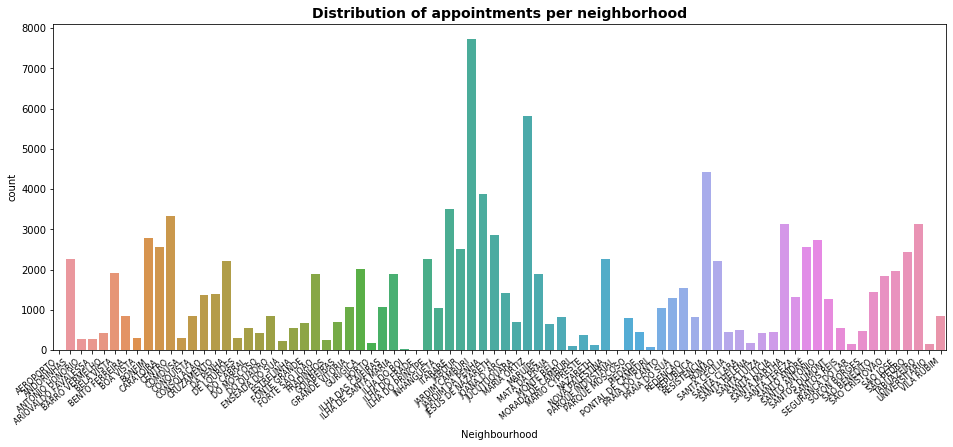

In [38]:
## Plotting an histogram with the neighborhoods sorted alphabetically. 
plt.figure(figsize=(16,6))
ax = sns.countplot(x='Neighbourhood', data=dataset, order=neighborhood)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right", fontsize=8)
plt.title('Distribution of appointments per neighborhood', fontsize=14, fontweight='bold')
plt.show()

In [39]:
## Counting gender classes
dataset['No-show'].value_counts()

No     88207
Yes    22312
Name: No-show, dtype: int64

In [40]:
## Reading the dataset attributes (columns):
dataset.columns

Index(['PatientId', 'Gender', 'ScheduledDay', 'AppointmentDay', 'Age',
       'Neighbourhood', 'Scholarship', 'Hipertension', 'Diabetes',
       'Alcoholism', 'Handcap', 'SMS_received', 'No-show', 'ScheduleTime',
       'WaitingDays', 'WaitingCategories'],
      dtype='object')

In [41]:
dataset = dataset.reindex(columns=['PatientId', 'Gender', 'Age', 'Scholarship', 'Hipertension', 'Diabetes',
       'Alcoholism', 'Handcap', 'ScheduledDay', 'ScheduleTime', 'AppointmentDay', 'WaitingDays', 'WaitingCategories', 'SMS_received', 
       'Neighbourhood', 'No-show'])

In [42]:
## Reading again the current attribute labels:
dataset.columns

Index(['PatientId', 'Gender', 'Age', 'Scholarship', 'Hipertension', 'Diabetes',
       'Alcoholism', 'Handcap', 'ScheduledDay', 'ScheduleTime',
       'AppointmentDay', 'WaitingDays', 'WaitingCategories', 'SMS_received',
       'Neighbourhood', 'No-show'],
      dtype='object')

In [43]:
## Renaming "No-show"to "No_show"; "Handcap" to "Handicap"; and "ScheduleTime" to "ScheduledTime":
dataset.columns = ['PatientId', 'Gender', 'Age', 'Scholarship', 'Hipertension', 'Diabetes',
       'Alcoholism', 'Handicap', 'ScheduledDay', 'ScheduledTime', 'AppointmentDay', 'WaitingDays', 
       'WaitingCategories', 'SMS_received', 'Neighbourhood', 'No_show']

In [44]:
## Checking again the dataset information (for numerical attributes) and description (for categorical ones):
print(dataset.info())
dataset.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 110519 entries, 5642903 to 5629448
Data columns (total 16 columns):
PatientId            110519 non-null object
Gender               110519 non-null object
Age                  110519 non-null int64
Scholarship          110519 non-null int64
Hipertension         110519 non-null int64
Diabetes             110519 non-null int64
Alcoholism           110519 non-null int64
Handicap             110519 non-null int32
ScheduledDay         110519 non-null datetime64[ns, UTC]
ScheduledTime        110519 non-null object
AppointmentDay       110519 non-null datetime64[ns, UTC]
WaitingDays          110519 non-null int64
WaitingCategories    110519 non-null category
SMS_received         110519 non-null int64
Neighbourhood        110519 non-null object
No_show              110519 non-null object
dtypes: category(1), datetime64[ns, UTC](2), int32(1), int64(7), object(5)
memory usage: 18.2+ MB
None


,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handicap,WaitingDays,SMS_received
count,110519.000000,110519.000000,110519.000000,110519.000000,110519.000000,110519.000000,110519.000000,110519.000000
mean,37.089071,0.098273,0.197260,0.071870,0.030402,0.020259,10.184005,0.321049
std,23.109970,0.297684,0.397932,0.258274,0.171692,0.140885,15.255082,0.466882
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000
75%,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,15.000000,1.000000
max,115.000000,1.000000,1.000000,1.000000,1.000000,1.000000,179.000000,1.000000


In [45]:
## Visualizing few instances of the data:
dataset.head(3)

,PatientId,Gender,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handicap,ScheduledDay,ScheduledTime,AppointmentDay,WaitingDays,WaitingCategories,SMS_received,Neighbourhood,No_show
AppointmentID,,,,,,,,,,,,,,,,
5642903,29872499824296,F,62,0,1,0,0,0,2016-04-29 00:00:00+00:00,18:38:08,2016-04-29 00:00:00+00:00,0,Same day: 0,0,JARDIM DA PENHA,No
5642503,558997776694438,M,56,0,0,0,0,0,2016-04-29 00:00:00+00:00,16:08:27,2016-04-29 00:00:00+00:00,0,Same day: 0,0,JARDIM DA PENHA,No
5642549,4262962299951,F,62,0,0,0,0,0,2016-04-29 00:00:00+00:00,16:19:04,2016-04-29 00:00:00+00:00,0,Same day: 0,0,MATA DA PRAIA,No


In [46]:
def get_statistics(data, bins=20):
    '''Prints basic statistics from the input data. 
    Syntax: get_statistics(data, bins=20), where:
        data = the input data series;
        bins = the number of bins to the histogram.
    '''
    total = data.values
    print('Mean:', np.mean(total))
    print('Standard deviation:', np.std(total))
    print('Minimum:', np.min(total))
    print('Maximum:', np.max(total))
    print('Median:', np.median(total))
    plt.hist(data, bins=bins);

In [47]:
def get_total(dataframe):
    '''Return the total sum of each numerical attribute of a pandas.Dataframe.'''
    return dataframe.sum(axis=1)

In [48]:
def df_row_normalize(dataframe):
    '''Normalizes the values of a given pandas.Dataframe by the total sum of each line.
    Algorithm based on https://stackoverflow.com/questions/26537878/pandas-sum-across-columns-and-divide-each-cell-from-that-value'''
    return dataframe.div(dataframe.sum(axis=1), axis=0)

In [49]:
def df_column_normalize(dataframe, percent=False):
    '''Normalizes the values of a given pandas.Dataframe by the total sum of each column.
    If percent=True, multiplies the final value by 100.
    Algorithm based on https://stackoverflow.com/questions/26537878/pandas-sum-across-columns-and-divide-each-cell-from-that-value'''
    if percent:
        return dataframe.div(dataframe.sum(axis=0), axis=1)*100
    else:
        return dataframe.div(dataframe.sum(axis=0), axis=1)

Mean: 10.18400456030185
Standard deviation: 15.255012525530072
Minimum: 0
Maximum: 179
Median: 4.0


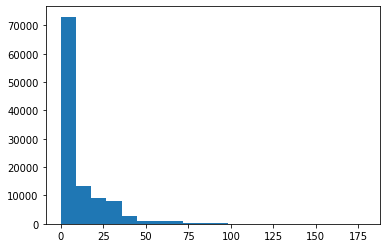

In [50]:
get_statistics(dataset.WaitingDays)


In [51]:
## Showing the data again:
waitingdays

No-show,No,Yes,No-showing rate
WaitingDays,,,
Same day: 0,36770.0,1792.0,4.873538
Short: 1-3,11316.0,3359.0,29.683634
Week: 4-7,13097.0,4413.0,33.694739
Fortnight: 8-15,9362.0,4166.0,44.499039
Month: 16-30,10709.0,5159.0,48.174433
Quarter: 31-90,6792.0,3369.0,49.602473
Semester: 91-180,161.0,56.0,34.782609
Very long: >180,0.0,0.0,NaN


In [53]:
## Adjusting the dataframe:
eda_waitingDays = waitingdays.copy()  #Copying the dataframe from Section 2.3.3
eda_waitingDays.reset_index(drop=False, inplace=True)  #Making the index as a column in order to be plotted.
eda_waitingDays.drop(7, inplace=True)  #Droppping the last row, since it's empty.

## Adding new columns:
#Transforming the 'No-showing rate' into strings with the percentual values:
eda_waitingDays['No-show percentual'] = eda_waitingDays['No-showing rate'].apply(lambda x: '{0:.2f}%'.format(x))
#Multiplying the rate values by 500 times in order to be plotted in the same scale:
eda_waitingDays['No-showing rate (500x)'] = eda_waitingDays['No-showing rate']*500

## Showing the adjusting dataframe:
eda_waitingDays

No-show,WaitingDays,No,Yes,No-showing rate,No-show percentual,No-showing rate (500x)
0,Same day: 0,36770.0,1792.0,4.873538,4.87%,2436.769105
1,Short: 1-3,11316.0,3359.0,29.683634,29.68%,14841.816896
2,Week: 4-7,13097.0,4413.0,33.694739,33.69%,16847.369627
3,Fortnight: 8-15,9362.0,4166.0,44.499039,44.50%,22249.519333
4,Month: 16-30,10709.0,5159.0,48.174433,48.17%,24087.216360
5,Quarter: 31-90,6792.0,3369.0,49.602473,49.60%,24801.236749
6,Semester: 91-180,161.0,56.0,34.782609,34.78%,17391.304348


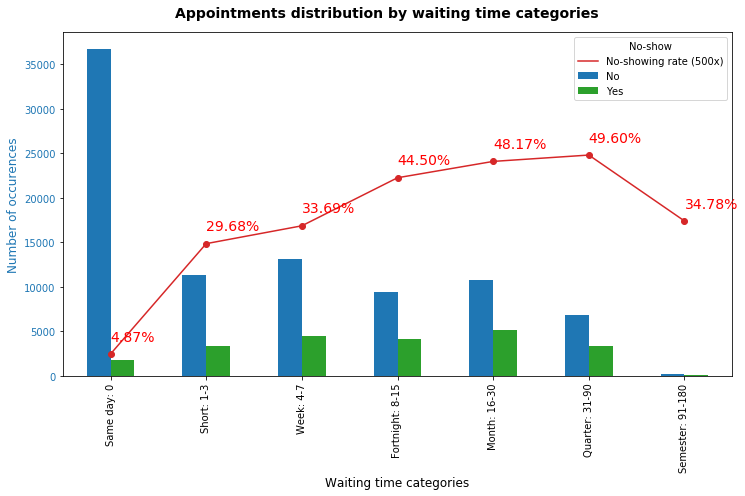

In [54]:
## Setting the graph parameters:
fig1, ax = plt.subplots(figsize=[12,6])  #Defines the graph window size
fig1.subplots_adjust(top=0.92)
plt.suptitle('Appointments distribution by waiting time categories', fontsize=14, fontweight='bold')

colors = ['tab:blue', 'tab:green', 'tab:red']  #Defines the colors to be used

ax.set_ylabel('Number of occurences', color=colors[0], fontsize=12)  #Set the y-axis color and label
ax.tick_params(axis='y', labelcolor=colors[0])

## Plotting the line chart:
eda_waitingDays[['WaitingDays', 'No-showing rate (500x)']].plot(x='WaitingDays', linestyle='-', marker='o', ax=ax, color=colors[2])
#Setting the line chart marker labels
x = ax.get_xticks()  #Getting the x-axis ticks to plot the label
for a,b,c in zip(x,eda_waitingDays['No-showing rate (500x)'], eda_waitingDays['No-show percentual']):
    plt.text(a,b+1500,c, color='red', fontsize=14)
    
## Plotting the bar chart:
eda_waitingDays[['WaitingDays', 'No', 'Yes']].plot(x='WaitingDays', kind='bar', ax=ax, color=colors[0:2])

ax.set_xlabel('Waiting time categories', fontsize=12)  #Set the y-axis color and label

plt.show()

In [55]:
## Group I - Describing the numerical attributes for the same day appointments:
group_I = dataset[dataset['WaitingCategories'] == 'Same day: 0'].describe()
group_I

,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handicap,WaitingDays,SMS_received
count,38562.000000,38562.000000,38562.000000,38562.000000,38562.000000,38562.000000,38562.0,38562.0
mean,34.452311,0.108656,0.175536,0.066542,0.039884,0.024169,0.0,0.0
std,23.221671,0.311211,0.380429,0.249231,0.195689,0.153575,0.0,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
25%,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
50%,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
75%,52.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
max,115.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,0.0


In [56]:
## Group II - Describing the numerical attributes for the semester appointments:
group_II = dataset[dataset['WaitingDays']>90].describe()
group_II

,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handicap,WaitingDays,SMS_received
count,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000
mean,60.788018,0.064516,0.539171,0.133641,0.013825,0.069124,121.410138,0.640553
std,25.672460,0.246238,0.499616,0.341052,0.117034,0.254252,31.423518,0.480948
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,91.000000,0.000000
25%,48.000000,0.000000,0.000000,0.000000,0.000000,0.000000,91.000000,0.000000
50%,69.000000,0.000000,1.000000,0.000000,0.000000,0.000000,109.000000,1.000000
75%,80.000000,0.000000,1.000000,0.000000,0.000000,0.000000,155.000000,1.000000
max,95.000000,1.000000,1.000000,1.000000,1.000000,1.000000,179.000000,1.000000


In [57]:
def find_differences(serie1, serie2, pct_diff):
    '''Given two data series [serie1, serie2], compare those attributes and return 
    those who difference among them is higher than pct_diff (e.g. 50% must be entered as 0.5).
    The index of both series must be identical.
    '''
    try:
        if (serie1.index.all() == serie2.index.all()):
            ## Calculating the differences
            testA = serie1 / serie2
            testB = serie2 / serie1
            checkA = [x for x in testA if (x > pct_diff)&(x<1)]
            checkB = [x for x in testB if (x > pct_diff)&(x<1)]
            
            ## Showing which attributes in serie1 are less than "pct_diff" of those in serie1:
            print('Attributes in "Serie I" whose values are less than {0:.1f}% of those in "Serie II":'.format(pct_diff*100))
            for item in checkA:
                print('\t{0}: {1:.1f}%'.format(testA[testA == item].index[0], item*100))
            
            ## Showing which attributes of serie2 are "pct_diff" higher in serie1:
            print('Attributes in "Serie II" whose values are less than {0:.1f}% of those in "Serie I":'.format(pct_diff*100))
            for item in checkB:
                print('\t{0}: {1:.1f}%'.format(testB[testB == item].index[0], item*100))
    except ValueError:
        print('The series must have same index and length!')
    return 

In [58]:
find_differences(group_I.loc['mean'], group_II.loc['mean'], 0.30)


Attributes in "Serie I" whose values are less than 30.0% of those in "Serie II":
	Age: 56.7%
	Hipertension: 32.6%
	Diabetes: 49.8%
	Handicap: 35.0%
Attributes in "Serie II" whose values are less than 30.0% of those in "Serie I":
	Scholarship: 59.4%
	Alcoholism: 34.7%


In [59]:
## Using the pandas.groupby() method to generate a pivot table:
neighbors_I = dataset.groupby(by='Neighbourhood').No_show.value_counts().sort_index()

In [60]:
## Manipulating the data:
neighbors_I = neighbors_I.unstack()  #Converting the groupby object into a dataset
neighbors_I.fillna(value=0, inplace=True)  #Replacing NaN values by zero
print(neighbors_I.head(3))

No_show              No    Yes
Neighbourhood                 
AEROPORTO           7.0    1.0
ANDORINHAS       1741.0  521.0
ANTÔNIO HONÓRIO   221.0   50.0


In [61]:
## Normalizing the data using a predefined function:
normalNeighbor = df_row_normalize(neighbors_I)
print(normalNeighbor.head(3))

No_show                No       Yes
Neighbourhood                      
AEROPORTO        0.875000  0.125000
ANDORINHAS       0.769673  0.230327
ANTÔNIO HONÓRIO  0.815498  0.184502


In [62]:
## Getting the normalized data statistics:
normalNeighbor.describe()

No_show,No,Yes
count,80.000000,80.000000
mean,0.804525,0.195475
std,0.038502,0.038502
min,0.710815,0.000000
25%,0.783269,0.179868
50%,0.802693,0.197307
75%,0.820132,0.216731
max,1.000000,0.289185


In [63]:
## Adding a total column:
neighbors_I['Total'] = get_total(neighbors_I)
normalNeighbor['Total'] = get_total(normalNeighbor)

In [64]:
#Reseting the 'neighbourhood' index and making it as a column:
neighbors_I.reset_index(inplace=True)  
normalNeighbor.reset_index(inplace=True)

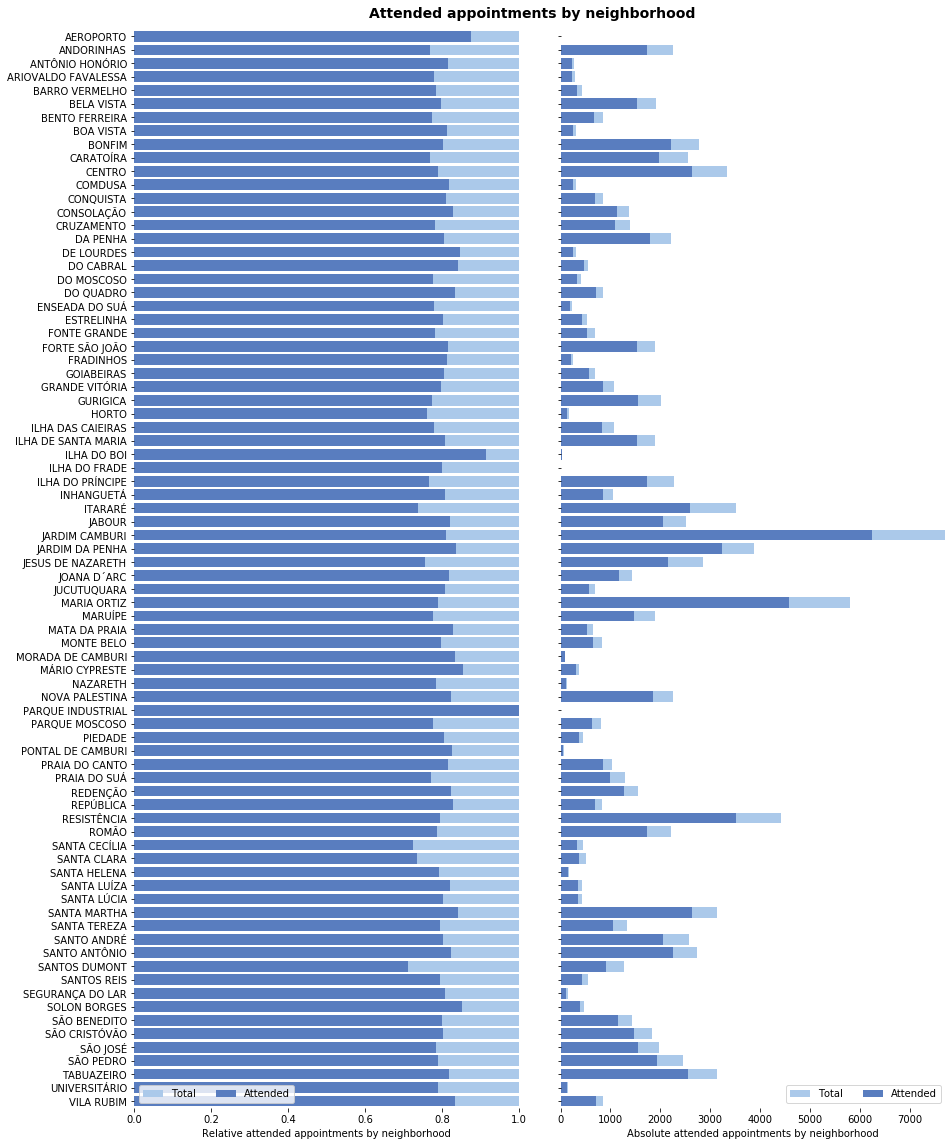

In [65]:
## Initialize the matplotlib figure:
fig2, (ax1, ax2) = plt.subplots(1,2, figsize=(12,16), sharey=False)
fig2.tight_layout()  #When working with 'tight_layout', the subplot must be adjusted [https://stackoverflow.com/questions/7066121/how-to-set-a-single-main-title-above-all-the-subplots-with-pyplot]
fig2.subplots_adjust(top=0.96)  #Adjusting the space for the superior title

## Plot the relative absence by neighborhood
#Total appointments
sns.set_color_codes("pastel")
sns.barplot(x="Total", y="Neighbourhood", data=normalNeighbor, label="Total", color="b", ax=ax1)
#Attended appointments
sns.set_color_codes("muted")
sns.barplot(x="No", y="Neighbourhood", data=normalNeighbor, label="Attended", color="b", ax=ax1)
## Add a legend and informative axis label
ax1.legend(ncol=2, loc="lower left", frameon=True)
ax1.set(xlim=(0, 1), ylabel="", xlabel="Relative attended appointments by neighborhood")
sns.despine(left=True, bottom=True,ax=ax1)

## Plot the absolute absence by neighborhood
#Total appointments
sns.set_color_codes("pastel")
sns.barplot(x="Total", y="Neighbourhood", data=neighbors_I, label="Total", color="b",ax=ax2)
#Attended appointments
sns.set_color_codes("muted")
sns.barplot(x="No", y="Neighbourhood", data=neighbors_I, label="Attended", color="b", ax=ax2)
## Add a legend and informative axis label
ax2.legend(ncol=2, loc="lower right", frameon=True)
ax2.set(xlim=(0, 7720), ylabel="", xlabel="Absolute attended appointments by neighborhood")  #The xlim value comes from the maximum value in the dataset.
ax2.set_yticklabels([''])
sns.despine(left=True, bottom=True, ax=ax2)

plt.suptitle('Attended appointments by neighborhood', fontsize=14, fontweight='bold')
plt.show()

In [66]:
## Using the pandas.groupby() method to produce a pivot table:
neighbors_II = dataset.groupby(by=['Neighbourhood','No_show']).WaitingCategories.value_counts().sort_index()

ValueError: Unknown format code 'd' for object of type 'float'

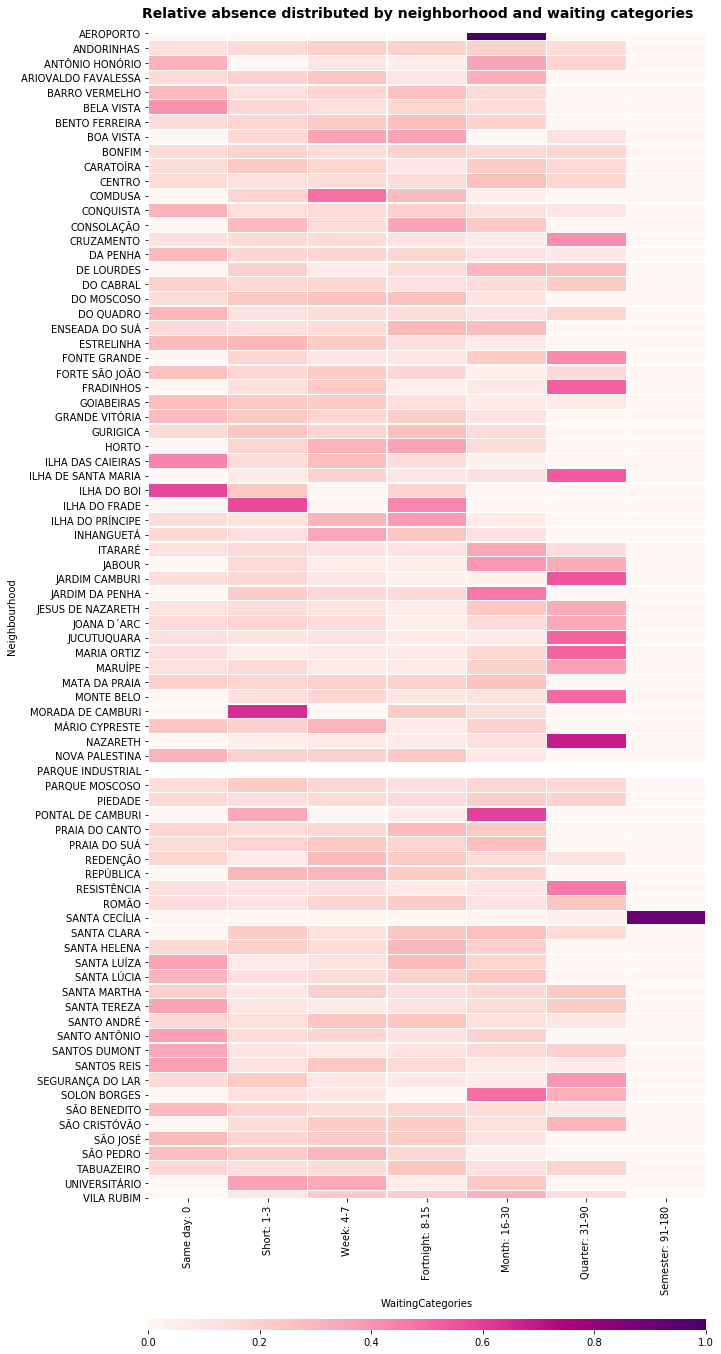

In [72]:
# Drawing a heatmap with the numeric values in each cell
fig3, ax = plt.subplots(figsize=(10, 25))
fig3.subplots_adjust(top=.965)
plt.suptitle('Relative absence distributed by neighborhood and waiting categories', fontsize=14, fontweight='bold')

cbar_kws = {'orientation':"horizontal", 'pad':0.08, 'aspect':50}
sns.heatmap(neighbors_II, annot=True, fmt='d', linewidths=.3, ax=ax, cmap='RdPu', cbar_kws=cbar_kws);

In [73]:
## Defining a new dataframe from the attributes of interest:
patients = dataset[['Gender','Age','Scholarship','Hipertension','Diabetes',
                    'Alcoholism','Handicap','WaitingCategories','SMS_received','No_show']]

In [74]:
## Obtaining an statistical overview of all the attributes:
patients.groupby(by=['No_show','WaitingCategories']).describe()

Age                                          \
                             count       mean        std  min    25%   50%   
No_show WaitingCategories                                                    
No      Same day: 0        36770.0  34.747648  23.275342  0.0  15.00  34.0   
        Short: 1-3         11316.0  43.441322  22.996905  0.0  25.00  47.0   
        Week: 4-7          13097.0  40.951057  22.738829  0.0  22.00  43.0   
        Fortnight: 8-15     9362.0  36.772805  22.674522  0.0  18.00  36.0   
        Month: 16-30       10709.0  37.680456  23.145006  0.0  18.00  38.0   
        Quarter: 31-90      6792.0  39.727326  23.501633  0.0  20.00  42.0   
        Semester: 91-180     161.0  63.248447  24.794160  0.0  52.00  71.0   
Yes     Same day: 0         1792.0  28.392299  21.207981  0.0  12.00  21.0   
        Short: 1-3          3359.0  39.450729  22.604173  0.0  20.00  40.0   
        Week: 4-7           4413.0  36.433265  21.641937  0.0  20.00  35.0   
        Fortnight: 8-15     4166.0  32.448392  21.414294  0.0  16.00  30.0   
        Month: 16-30        5157.0  33.036843  21.210556  0.0  16.00  31.0   
        Quarter: 31-90      3369.0  33.519442  22.396125  0.0  14.00  32.0   
        Semester: 91-180      56.0  53.714286  27.043207  0.0  41.75  59.5   

                                        Scholarship            ... Handicap  \
                             75%    max       count      mean  ...      75%   
No_show WaitingCategories                                      ...            
No      Same day: 0        53.00  115.0     36770.0  0.107289  ...      0.0   
        Short: 1-3         61.00  102.0     11316.0  0.076264  ...      0.0   
        Week: 4-7          59.00   97.0     13097.0  0.086585  ...      0.0   
        Fortnight: 8-15    54.00  115.0      9362.0  0.104251  ...      0.0   
        Month: 16-30       56.00  100.0     10709.0  0.090018  ...      0.0   
        Quarter: 31-90     58.00   98.0      6792.0  0.057715  ...      0.0   
        Semester: 91-180   82.00   94.0       161.0  0.055901  ...      0.0   
Yes     Same day: 0        44.00   97.0      1792.0  0.136719  ...      0.0   
        Short: 1-3         57.00  115.0      3359.0  0.095862  ...      0.0   
        Week: 4-7          53.00   95.0      4413.0  0.119420  ...      0.0   
        Fortnight: 8-15    48.00   98.0      4166.0  0.140663  ...      0.0   
        Month: 16-30       48.00   95.0      5157.0  0.115765  ...      0.0   
        Quarter: 31-90     51.00  115.0      3369.0  0.087860  ...      0.0   
        Semester: 91-180   76.25   95.0        56.0  0.089286  ...      0.0   

                               SMS_received                                \
                           max        count      mean       std  min  25%   
No_show WaitingCategories                                                   
No      Same day: 0        1.0      36770.0  0.000000  0.000000  0.0  0.0   
        Short: 1-3         1.0      11316.0  0.063008  0.242988  0.0  0.0   
        Week: 4-7          1.0      13097.0  0.617775  0.485950  0.0  0.0   
        Fortnight: 8-15    1.0       9362.0  0.605853  0.488693  0.0  0.0   
        Month: 16-30       1.0      10709.0  0.630124  0.482793  0.0  0.0   
        Quarter: 31-90     1.0       6792.0  0.643698  0.478941  0.0  0.0   
        Semester: 91-180   1.0        161.0  0.633540  0.483340  0.0  0.0   
Yes     Same day: 0        1.0       1792.0  0.000000  0.000000  0.0  0.0   
        Short: 1-3         1.0       3359.0  0.057458  0.232750  0.0  0.0   
        Week: 4-7          1.0       4413.0  0.578065  0.493924  0.0  0.0   
        Fortnight: 8-15    1.0       4166.0  0.541287  0.498352  0.0  0.0   
        Month: 16-30       1.0       5157.0  0.552453  0.497289  0.0  0.0   
        Quarter: 31-90     1.0       3369.0  0.563669  0.496003  0.0  0.0   
        Semester: 91-180   1.0         56.0  0.660714  0.477752  0.0  0.0   

                                          
       

In [75]:
## Grouping by classes and waiting categories and calculating the instances sum:
patients_sum = patients.groupby(by=['No_show','WaitingCategories']).sum()
## Grouping by classes and waiting categories and calculating the instances sum:
patients_mean = patients.groupby(by=['No_show','WaitingCategories']).mean()

In [76]:
## Adjusting the 'Age' attribute to have the mean instead of sum values:
patients = patients_sum.copy()
patients['Age'] = patients_mean['Age']

In [77]:
## Normalizing data using the predefined function
patients = df_column_normalize(patients, percent=True)

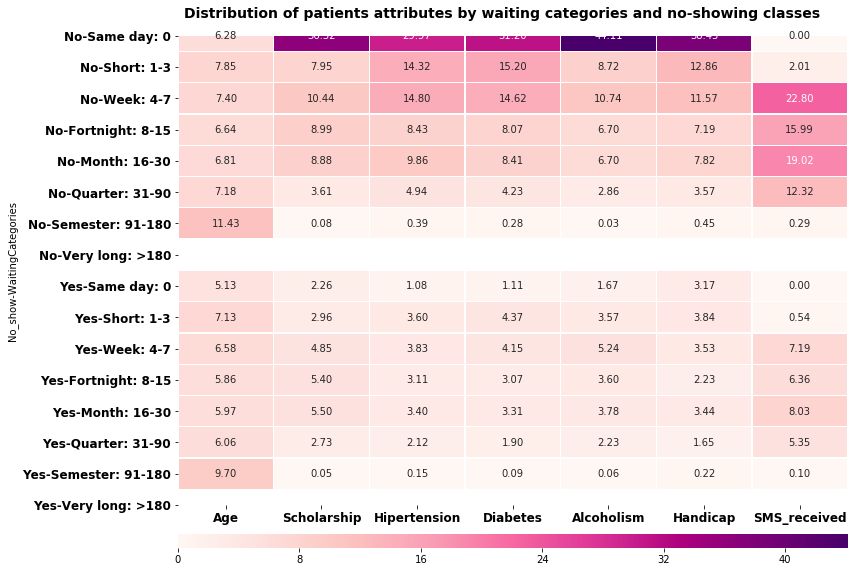

In [78]:
fig4, ax = plt.subplots(figsize=(12, 10))
fig4.subplots_adjust(top=.94)
plt.suptitle('Distribution of patients attributes by waiting categories and no-showing classes', fontsize=14, fontweight='bold')

ax.set_yticklabels(ax.get_yticklabels(), ha="right", fontsize=12, weight='bold')
ax.set_xticklabels(ax.get_xticklabels(), fontsize=12, weight='bold')

cbar_kws = {'orientation':"horizontal", 'pad':0.05, 'aspect':50}
sns.heatmap(patients, annot=True, fmt='.2f', linewidths=.3, ax=ax, cmap='RdPu', cbar_kws=cbar_kws);